<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/OTProcessNetworkDataFusion_Version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Background:

This notebook demonstrates the **fusion of network anomaly scores and process classification results** for cyber-physical threat detection, with the goal of assessing the **generalization capability** of detection models across:
  - **Seen data** (instances 1 – 50): normal and single-vector attack behaviors
  - **Unseen data** (instances 51 – 60): multi-vector, stealthy attack scenarios

The datasets provides a side-by-side comparison of the anomaly socres for all 60 instances:
  - **Network-only detection** using Isolation Forest
  - **Process-only detection** using LSTM-FCN Time Series Classifier
  - **Fusion detection** using combined logic

The results show that **fusion improves detection performance (accuracy, F1 Score)**, especially in identifying **unseen and stealthy multi-vector Advanced Persistent Threat (APT)** behaviors (instance 51 - 60).




# Step 1: Loading the process data and network data


In [7]:
# Step 1: network data and process data
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load Network Data with Anomaly Scores calculated by Isolation Forest
df_network = pd.read_csv("instance_anomaly_summary.csv")

# Check format
df_network['instance'] = df_network['instance'].astype(int)

Saving instance_anomaly_summary.csv to instance_anomaly_summary.csv


In [49]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.25,anomaly_0.25,label
0,1,0,0.000000,584,0.234256,2493,0.115396,1,0
1,2,0,0.000000,514,0.233424,2202,-0.076033,-1,0
2,3,0,0.000000,583,0.234231,2489,0.146823,1,0
3,4,0,0.000000,572,0.234234,2442,0.148887,1,0
4,5,0,0.000000,540,0.234070,2307,0.152311,1,0
5,6,0,0.000000,590,0.234406,2517,-0.007075,-1,0
6,7,0,0.000000,569,0.233868,2433,0.021224,1,0
7,8,0,0.000000,584,0.234068,2495,0.154344,1,0
8,9,0,0.000000,576,0.230124,2503,-0.282645,-1,0
9,10,0,0.000000,576,0.234051,2461,0.128183,1,0


In [8]:
# Check instance field for process data
print(df_network['instance'].min(), df_network['instance'].max())

1 60


In [36]:
# -1 anaomly, 1 is normal
print(df_network['anomaly_0.25'].value_counts())

anomaly_0.25
-1    44
 1    16
Name: count, dtype: int64


In [6]:
uploaded = files.upload()

# Load Process Data with Class Scores calculated by LSTM-FCN
df_process = pd.read_csv("NX_process_predictions_all60_with_label.csv")

# Check format
df_process['Instance'] = df_process['Instance'].astype(int)

Saving NX_process_predictions_all60_with_label.csv to NX_process_predictions_all60_with_label.csv


In [48]:
df_process

,Instance,Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Ground Truth,Label_Description
0,1,0,99.99%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
1,2,0,99.99%,0.0%,0.01%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
2,3,0,99.98%,0.0%,0.01%,0.0%,0.01%,0,Label 0: Normal_NoIntervention
3,4,2,0.61%,0.03%,99.23%,0.02%,0.11%,0,Label 0: Normal_NoIntervention
4,5,0,100.0%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
5,6,0,100.0%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
6,7,0,99.99%,0.0%,0.01%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
7,8,0,100.0%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
8,9,0,99.96%,0.0%,0.02%,0.0%,0.01%,0,Label 0: Normal_NoIntervention
9,10,0,100.0%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention


In [9]:
# Check instance field for network data
print(df_network['instance'].min(), df_network['instance'].max())

1 60


# Step 2 Merge and normalize

In [14]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Merge on instance number
df_merged = pd.merge(df_network, df_process, left_on='instance', right_on='Instance')

# Convert percentage % to float
for col in [f'Prob_Class_{i}' for i in range(5)]:
    df_merged[col] = df_merged[col].str.replace('%', '').astype(float)

# Normalize network score (Isolation Forest anomaly_score_0.25)
scaler = MinMaxScaler()
df_merged['network_score'] = scaler.fit_transform(df_merged[['anomaly_score_0.25']])

# Use max(Prob_Class_1 to 4) as process_score
df_merged['process_score'] = df_merged[[f'Prob_Class_{i}' for i in range(1, 5)]].max(axis=1)

In [24]:
df_merged[['instance', 'network_score', 'process_score', 'label']]

,instance,network_score,process_score,label
0,1,0.910872,0.00,0
1,2,0.472809,0.01,0
2,3,0.982791,0.01,0
3,4,0.987513,99.23,0
4,5,0.995348,0.00,0
5,6,0.630612,0.00,0
6,7,0.695370,0.01,0
7,8,1.000000,0.00,0
8,9,0.000000,0.02,0
9,10,0.940134,0.00,0


In [25]:
# Check instance field for network data
print(df_merged['instance'].min(), df_merged['instance'].max())

1 60


# Step 3: Fusion logic and evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# Define binary predictions
df_merged['network_pred'] = df_merged['anomaly_0.25'].apply(lambda x: 1 if x == -1 else 0)
df_merged['process_pred'] = df_merged['Predicted_Label'].apply(lambda x: 1 if x in [1,2,3,4] else 0)
df_merged['fused_pred'] = df_merged.apply(
    lambda row: 1 if (row['network_pred'] == 1 or row['process_pred'] == 1) else 0,
    axis=1
)

# Evaluate against Ground Truth (binary: 0 = normal, 1 = attack or anomaly)
df_merged['y_true'] = df_merged['label'].apply(lambda x: 0 if x == 0 else 1)

In [50]:
df_merged[['instance', 'label', 'y_true', 'network_pred', 'process_pred', 'fused_pred']]

,instance,label,y_true,network_pred,process_pred,fused_pred
0,1,0,0,0,0,0
1,2,0,0,1,0,1
2,3,0,0,0,0,0
3,4,0,0,0,1,1
4,5,0,0,0,0,0
5,6,0,0,1,0,1
6,7,0,0,0,0,0
7,8,0,0,0,0,0
8,9,0,0,1,0,1
9,10,0,0,0,0,0


In [39]:
df_merged['y_true'] = df_merged['label'].apply(lambda x: 0 if x == 0 else 1)

# Split subset for seen (1–50) and unseen (51–60)
seen = df_merged[df_merged['instance'] <= 50]
unseen = df_merged[df_merged['instance'] > 50]

# Function for printing performance
from sklearn.metrics import classification_report

def evaluate_predictions(df, title):
    print(f"\n=== {title} ===")
    for col in ['network_pred', 'process_pred', 'fused_pred']:
        print(f"--- {col} ---")
        print(classification_report(df['y_true'], df[col]))

# Evaluate on seen and unseen separately
evaluate_predictions(seen, "Evaluation on Seen Instances (1–50)")
evaluate_predictions(unseen, "Evaluation on Unseen Multi-Vector (51–60)")


=== Evaluation on Seen Instances (1–50) ===
--- network_pred ---
              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.92      0.88      0.90        40

    accuracy                           0.84        50
   macro avg       0.75      0.79      0.77        50
weighted avg       0.85      0.84      0.85        50

--- process_pred ---
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.98      1.00      0.99        40

    accuracy                           0.98        50
   macro avg       0.99      0.95      0.97        50
weighted avg       0.98      0.98      0.98        50

--- fused_pred ---
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        10
           1       0.91      1.00      0.95        40

    accuracy                           0.92        50
   macro avg       0.9

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

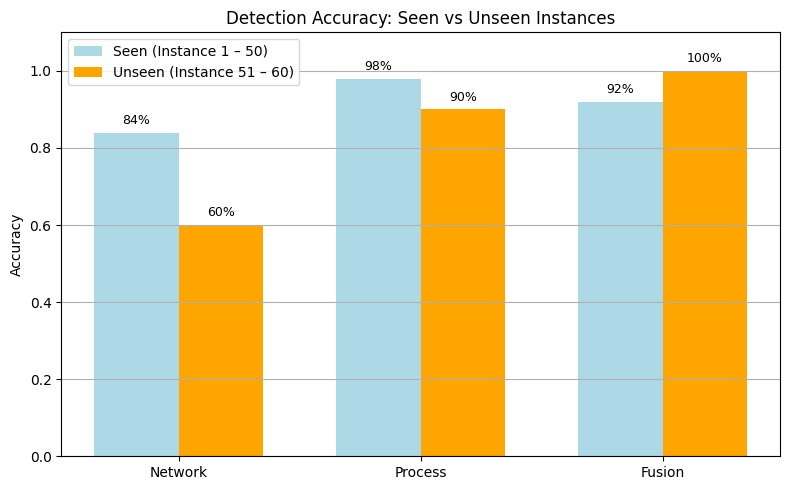

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Create subsets
seen = df_merged[df_merged['instance'] <= 50]
unseen = df_merged[df_merged['instance'] > 50]

# Accuracy for each method on both subsets
seen_acc = {
    'Network': accuracy_score(seen['y_true'], seen['network_pred']),
    'Process': accuracy_score(seen['y_true'], seen['process_pred']),
    'Fusion': accuracy_score(seen['y_true'], seen['fused_pred'])
}

unseen_acc = {
    'Network': accuracy_score(unseen['y_true'], unseen['network_pred']),
    'Process': accuracy_score(unseen['y_true'], unseen['process_pred']),
    'Fusion': accuracy_score(unseen['y_true'], unseen['fused_pred'])
}

# Plot grouped bars
labels = list(seen_acc.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, list(seen_acc.values()), width, label='Seen (Instance 1 – 50)', color='lightblue')
bars2 = ax.bar(x + width/2, list(unseen_acc.values()), width, label='Unseen (Instance 51 – 60)', color='orange')

# Annotate bars with accuracy %
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height*100:.0f}%',  # ← percent format
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Formatting
ax.set_ylabel('Accuracy')
ax.set_title('Detection Accuracy: Seen vs Unseen Instances')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

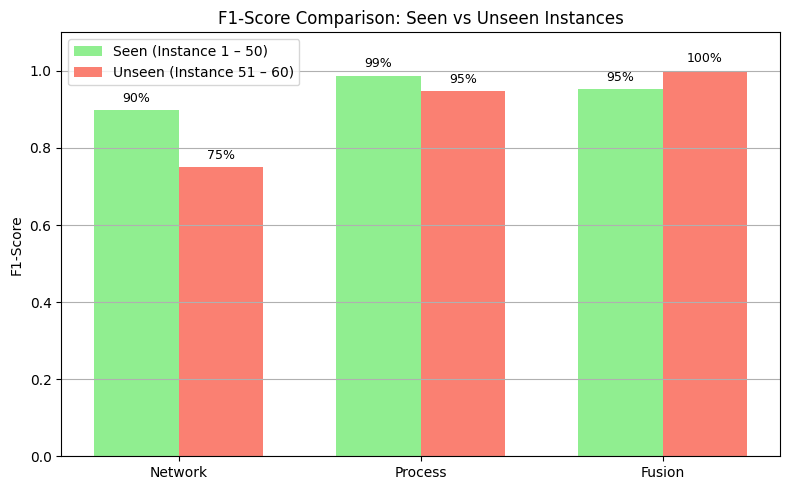

In [46]:
from sklearn.metrics import f1_score

# F1-scores for seen and unseen data
seen_f1 = {
    'Network': f1_score(seen['y_true'], seen['network_pred']),
    'Process': f1_score(seen['y_true'], seen['process_pred']),
    'Fusion': f1_score(seen['y_true'], seen['fused_pred'])
}

unseen_f1 = {
    'Network': f1_score(unseen['y_true'], unseen['network_pred']),
    'Process': f1_score(unseen['y_true'], unseen['process_pred']),
    'Fusion': f1_score(unseen['y_true'], unseen['fused_pred'])
}

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, list(seen_f1.values()), width, label='Seen (Instance 1 – 50)', color='lightgreen')
bars2 = ax.bar(x + width/2, list(unseen_f1.values()), width, label='Unseen (Instance 51 – 60)', color='salmon')

# Annotate
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height*100:.0f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Style
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison: Seen vs Unseen Instances')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


The end